In [338]:
expr_name = "feynman_comparison"
which_config = 2  # 0 for Synthetic, 1 for Syn2, 2 for Feynman
single_plot = False
pysr_overall = False  # Set to False to exclude PySR from the overall comparison plot
if_grouped = True  # Set to True to use grouped bar chart with gradient colors, False for original style

# New parameters for controlling plot order and equation selection
plot_sequence = []
plot_equations = [1,2,3,4,5,6,7,8,9,10]  # Show all 10 equations for Feynman

# for v4 cmp_scaling_weights
# plot_sequence = [0,5,1,6]  # Order of experiments to display (by exp_labels keys)
# plot_equations = [2,4,10]  # Which equations to plot (by equation number)
# plot_equations = [6,7]  # Which equations to plot (by equation number)

In [339]:
if which_config == 0:
    # Define experiment labels and colors - dynamically extended to support any experiment number
    base_path = "lasr_runs_synthetic_llama32"
    
    # Multiple PySR baselines with different iterations
    pysr_baselines = {
        10: "pysr_runs_baseline_synthetic/exp_0/summary.txt",
        20: "pysr_runs_baseline_synthetic/exp_1/summary.txt", 
        40: "pysr_runs_baseline_synthetic/exp_2/summary.txt",
        100: "pysr_runs_baseline_synthetic/exp_3/summary.txt",
        400: "pysr_runs_baseline_synthetic/exp_4/summary.txt",
        1000: "pysr_runs_baseline_synthetic/exp_5/summary.txt"
    }

    # Determine dataset type for saving plots
    dataset_type = "syn/loss_plot"  # This will be used for saving plots

    # CONFIGURABLE: Define which experiments to include in the analysis
    # Comment/uncomment experiments as needed
    exp_labels = {
        # PySR baselines - multiple iterations
        'pysr_10': 'PySR (10)',
        # 'pysr_20': 'PySR (20)', 
        # 'pysr_40': 'PySR (40)',
        # 'pysr_100': 'PySR (100)',
        # 'pysr_400': 'PySR (400)',
        'pysr_1000': 'PySR (1000)',
        
        # LASR experiments
        # 0: 'Llama3.2',
        # 1: 'Llama3.2 p',
        # 2: 'Llama3.2 ph',
        # 3: 'Llama3.2',
        4: 'Qwen3-8B',
        5: 'Qwen3-8B-think',
        6: 'DeepSeek V3',
        7: 'DeepSeek R1',
        # 9: 'Llama3.2 p*',
        # # 8: 'Qwen3-8B ',
        # 10: 'Qwen3-8B p*',
        # 11: 'Qwen3-8B-think p*',
        # 12: 'Deepseek-V3 p*',
    }

    # Generate gradient colors for each group
    def generate_gradient_colors(base_color, n_shades):
        """Generate gradient colors from light to dark for a base color."""
        import matplotlib.colors as mcolors
        rgb = mcolors.to_rgb(base_color)
        colors = []
        for i in range(n_shades):
            # Create gradient from light (0.3) to dark (1.0)
            factor = 0.3 + (0.7 * i / (n_shades - 1)) if n_shades > 1 else 1.0
            # Mix with white for lighter shades
            color = tuple(1 - (1 - c) * factor for c in rgb)
            colors.append(mcolors.to_hex(color))
        return colors

    # Define experiment groups for gradient colors
    experiment_groups = {
        'pysr': ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000'],
        'llama': [0, 1, 2, 3, 9],
        'qwen': [4, 10],
        'qwen_think': [5, 11],
        'deepseek_v3': [6, 12],
        'deepseek_r1': [7]
    }

    # Base colors for each group
    group_base_colors = {
        'pysr': '#d62728',      # Red
        'llama': '#1f77b4',     # Blue
        'qwen': '#ff7f0e',      # Orange
        'qwen_think': '#2ca02c', # Green
        'deepseek_v3': '#9467bd', # Purple
        'deepseek_r1': '#8c564b'  # Brown
    }

    # Generate gradient colors for each group
    exp_colors = {}
    for group_name, exp_keys in experiment_groups.items():
        base_color = group_base_colors[group_name]
        # Filter to only include experiments that are defined in exp_labels
        active_keys = [k for k in exp_keys if k in exp_labels]
        if active_keys:
            gradient_colors = generate_gradient_colors(base_color, len(active_keys))
            for i, exp_key in enumerate(active_keys):
                exp_colors[exp_key] = gradient_colors[i]

    equation_info = {
        1: {
            'name': 'Damped Sinusoid',
            'formula': 'sin(x)*exp(-y²/2)',
            'description': 'A damped sinusoidal function in 2D space, combining periodic and exponential decay'
        },
        2: {
            'name': '3D Euclidean Distance', 
            'formula': 'sqrt(x² + y² + z²)',
            'description': 'The Euclidean distance function in 3D space, representing the distance from origin'
        },
        3: {
            'name': 'Softplus-Lorentzian',
            'formula': 'log(1 + exp(x))/(1 + y²)',
            'description': 'A softplus function modulated by a Lorentzian function, combining smooth activation and decay'
        },
        4: {
            'name': 'Trigonometric Product',
            'formula': 'sin(x*y)*cos(z*w)',
            'description': 'A product of two trigonometric functions in 4D space, creating complex wave patterns'
        },
        5: {
            'name': '3D Gaussian PDF',
            'formula': 'exp(-(x² + y² + z²)/(2σ²))/((2π)σ²)^(3/2)',
            'description': 'A 3D Gaussian probability density function with variable standard deviation'
        },
        6: {
            'name': 'Logarithmic Spiral',
            'formula': 'x*cos(log(sqrt(x² + y²) + ε)) + y*sin(log(sqrt(x² + y²) + ε))',
            'description': 'A logarithmic spiral function combining polar coordinates with trigonometric transformations'
        },
        7: {
            'name': 'Directional Field',
            'formula': 'y/(x + ε)*exp(-(x² + y²)/4)',
            'description': 'A directional field function with exponential decay modulation in polar coordinates'
        },
        8: {
            'name': 'Hyperbolic Approximation',
            'formula': '(exp(x) - exp(-x))*(exp(y) - exp(-y))/(1 + z²)',
            'description': 'A hyperbolic approximation using exponential differences creating wave interference patterns'
        },
        9: {
            'name': 'Rational Polynomial',
            'formula': '(x³ - 2*x*y + y²)/(x² + y² + 1)',
            'description': 'A rational polynomial function with cubic numerator and quadratic denominator normalization'
        },
        10: {
            'name': 'Sigmoid Mixture',
            'formula': 'x/(1 + exp(-y)) + z/(1 + exp(y))',
            'description': 'A sigmoid-gated mixture function simulating neural network activation and inhibition patterns'
        }
    }

In [340]:
if which_config == 1:
    base_path = "lasr_syn2"
    
    # Multiple PySR baselines with different iterations
    pysr_baselines = {
        10: "pysr_syn2/exp_0/summary.txt",
        20: "pysr_syn2/exp_1/summary.txt",
        40: "pysr_syn2/exp_2/summary.txt",
        100: "pysr_syn2/exp_3/summary.txt",
        400: "pysr_syn2/exp_4/summary.txt",
        1000: "pysr_syn2/exp_5/summary.txt"
    }

    # Determine dataset type for saving plots
    dataset_type = "syn2/loss_plot"  # This will be used for saving plots

    exp_labels = {
        # PySR baselines - multiple iterations
        'pysr_10': 'PySR (10)',
        # 'pysr_20': 'PySR (20)',
        'pysr_40': 'PySR (40)',
        # 'pysr_100': 'PySR (100)',
        # 'pysr_400': 'PySR (400)',
        'pysr_1000': 'PySR (1000)',
        
        # LASR experiments
        0: 'Llama3.2',
        1: 'Qwen3-8B',
        2: 'Qwen3-8B-think',
        3: 'DeepSeek V3',
        4: 'DeepSeek R1',
        5: 'Llama3.2 pw',
        6: 'Qwen3-8B pw',
        7: 'Qwen3-8B-think pw',
        8: 'DeepSeek V3 pw',
        # 9: 'N/A',
        10: 'Deepseek V3 pw 40 it',
        11: 'DeepSeek V3 1e-2',
        12: 'DeepSeek R1 pw',
    }

    # Generate gradient colors for each group
    def generate_gradient_colors(base_color, n_shades):
        """Generate gradient colors from light to dark for a base color."""
        import matplotlib.colors as mcolors
        rgb = mcolors.to_rgb(base_color)
        colors = []
        for i in range(n_shades):
            # Create gradient from light (0.3) to dark (1.0)
            factor = 0.3 + (0.7 * i / (n_shades - 1)) if n_shades > 1 else 1.0
            # Mix with white for lighter shades
            color = tuple(1 - (1 - c) * factor for c in rgb)
            colors.append(mcolors.to_hex(color))
        return colors

    # Define experiment groups for gradient colors
    experiment_groups = {
        'pysr': ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000'],
        'llama': [0, 5],
        'qwen': [1, 6],
        'qwen_think': [2, 7],
        'deepseek_v3': [3, 8, 11, 10],
        'deepseek_r1': [4, 12]
    }

    # Base colors for each group
    group_base_colors = {
        'pysr': '#d62728',      # Red
        'llama': '#1f77b4',     # Blue
        'qwen': '#ff7f0e',      # Orange
        'qwen_think': '#2ca02c', # Green
        'deepseek_v3': '#9467bd', # Purple
        'deepseek_r1': '#8c564b'  # Brown
    }

    # Generate gradient colors for each group
    exp_colors = {}
    for group_name, exp_keys in experiment_groups.items():
        base_color = group_base_colors[group_name]
        # Filter to only include experiments that are defined in exp_labels
        active_keys = [k for k in exp_keys if k in exp_labels]
        if active_keys:
            gradient_colors = generate_gradient_colors(base_color, len(active_keys))
            for i, exp_key in enumerate(active_keys):
                exp_colors[exp_key] = gradient_colors[i]

    equation_info = {
        1: {
            'name': 'Squared-Sine-Exp-Log',
            'formula': 'sin(x*y)² * exp(-z/2) + log(1 + w)',
            'description': 'A squared sinusoidal product with exponential decay plus logarithmic term'
        },
        2: {
            'name': 'Softplus-Cosine Product',
            'formula': 'log(1 + exp(x)) * cos(y*z)',
            'description': 'A softplus function multiplied by a cosine of product'
        },
        3: {
            'name': 'Root-SquaredSine-ExpCos',
            'formula': 'sqrt(x*y) * sin(z)² + exp(-w) * cos(x)',
            'description': 'A square root of product with squared sine plus exponential decay times cosine'
        },
        4: {
            'name': 'Linear-Cosine-Log',
            'formula': 'x*cos(y) + log(1 + z*w)',
            'description': 'A linear cosine term combined with logarithm of product'
        },
        5: {
            'name': 'Exp-Ratio-Sine-Quad',
            'formula': 'exp(x/y) * sin(z) / (1 + w²)',
            'description': 'An exponential ratio multiplied by sine and normalized by quadratic term'
        },
        6: {
            'name': 'Squared-Sum-Exp-Sine',
            'formula': '(x + y)² * exp(-z/3) + sin(w)',
            'description': 'A squared sum with exponential decay plus sine term'
        },
        7: {
            'name': 'SquaredSine-Sigmoid-Log',
            'formula': 'sin(x*y)² / (1 + exp(-z)) + log(1 + x²)',
            'description': 'A squared sine product normalized by sigmoid plus logarithmic quadratic'
        },
        8: {
            'name': 'SquaredLog-Cosine-SquaredSine',
            'formula': 'log(x*y + 1)² * cos(z) - sin(w)²',
            'description': 'A squared logarithm of shifted product times cosine minus squared sine'
        },
        9: {
            'name': 'Exp-Sum-SquaredSine-Ratio',
            'formula': 'sqrt(exp(x) + exp(y)) * sin(z/w)²',
            'description': 'A square root of exponential sum multiplied by squared sine of ratio'
        },
        10: {
            'name': 'Linear-Trig-Exp',
            'formula': 'x*sin(y) + z*cos(w) + exp(-v/2)',
            'description': 'A linear combination of trigonometric terms with exponential decay'
        }
    }

In [341]:
if which_config == 2:
    # Feynman dataset configuration
    base_path = "lasr_feynman"
    
    # Multiple PySR baselines with different iterations for Feynman
    pysr_baselines = {
        10: "pysr_feynman/exp_0/summary.txt",
        40: "pysr_feynman/exp_1/summary.txt",
        100: "pysr_feynman/exp_3/summary.txt",
        400: "pysr_feynman/exp_2/summary.txt",
    }

    # Determine dataset type for saving plots
    dataset_type = "feynman/loss_plot"  # This will be used for saving plots

    exp_labels = {
        # PySR baselines - multiple iterations
        'pysr_10': 'PySR (10)',
        'pysr_40': 'PySR (40)',
        'pysr_100': 'PySR (100)',
        'pysr_400': 'PySR (400)',
        
        # LASR experiments - only DeepSeek V3 based on run_f_deepseek_v3.sh
        # 0: 'DeepSeek V3 1e-3',
        1: 'DeepSeek V3 3e-3 40it', 
    }

    # Generate gradient colors for each group
    def generate_gradient_colors(base_color, n_shades):
        """Generate gradient colors from light to dark for a base color."""
        import matplotlib.colors as mcolors
        rgb = mcolors.to_rgb(base_color)
        colors = []
        for i in range(n_shades):
            # Create gradient from light (0.3) to dark (1.0)
            factor = 0.3 + (0.7 * i / (n_shades - 1)) if n_shades > 1 else 1.0
            # Mix with white for lighter shades
            color = tuple(1 - (1 - c) * factor for c in rgb)
            colors.append(mcolors.to_hex(color))
        return colors

    # Define experiment groups for gradient colors
    experiment_groups = {
        'pysr': ['pysr_10', 'pysr_40', 'pysr_100', 'pysr_400'],
        'deepseek_v3': [0, 1]
    }

    # Base colors for each group
    group_base_colors = {
        'pysr': '#d62728',      # Red
        'deepseek_v3': '#9467bd', # Purple
    }

    # Generate gradient colors for each group
    exp_colors = {}
    for group_name, exp_keys in experiment_groups.items():
        base_color = group_base_colors[group_name]
        # Filter to only include experiments that are defined in exp_labels
        active_keys = [k for k in exp_keys if k in exp_labels]
        if active_keys:
            gradient_colors = generate_gradient_colors(base_color, len(active_keys))
            for i, exp_key in enumerate(active_keys):
                exp_colors[exp_key] = gradient_colors[i]

    # Feynman equation info - only top 10 equations (indices 0-9, which are equations 1-10)
    equation_info = {
        1: {
            'name': 'Gaussian Distribution',
            'formula': 'exp(-θ²/2)/√(2π)',
            'description': 'I.6.2a - Normal distribution probability density function'
        },
        2: {
            'name': 'Gaussian with Sigma',
            'formula': 'exp(-(θ/σ)²/2)/(√(2π)σ)',
            'description': 'I.6.2 - Normal distribution with standard deviation'
        },
        3: {
            'name': 'Shifted Gaussian',
            'formula': 'exp(-((θ-θ₁)/σ)²/2)/(√(2π)σ)',
            'description': 'I.6.2b - Normal distribution with mean shift'
        },
        4: {
            'name': '2D Euclidean Distance',
            'formula': '√((x₂-x₁)² + (y₂-y₁)²)',
            'description': 'I.8.14 - Distance between two points in 2D'
        },
        5: {
            'name': 'Gravitational Force',
            'formula': 'Gm₁m₂/((x₂-x₁)² + (y₂-y₁)² + (z₂-z₁)²)',
            'description': 'I.9.18 - Newton\'s law of universal gravitation in 3D'
        },
        6: {
            'name': 'Relativistic Mass',
            'formula': 'm₀/√(1 - v²/c²)',
            'description': 'I.10.7 - Relativistic mass increase'
        },
        7: {
            'name': '3D Dot Product',
            'formula': 'x₁y₁ + x₂y₂ + x₃y₃',
            'description': 'I.11.19 - Scalar product of two 3D vectors'
        },
        8: {
            'name': 'Friction Force',
            'formula': 'μNn',
            'description': 'I.12.1 - Frictional force'
        },
        9: {
            'name': 'Kinetic Energy 3D',
            'formula': '½m(v² + u² + w²)',
            'description': 'I.13.4 - Kinetic energy in three dimensions'
        },
        10: {
            'name': 'Coulomb Force',
            'formula': 'q₁q₂r/(4πεr³)',
            'description': 'I.12.2 - Coulomb\'s law for electric force'
        }
    }

In [342]:
# Import required libraries
import re
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict
import pandas as pd
from pathlib import Path

# Set plot style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Function to auto-detect available experiments
def detect_available_experiments(base_path):
    """Auto-detect all available exp_N directories with actual summary.txt data."""
    base_path = Path(base_path)
    available_experiments = []
    
    if not base_path.exists():
        print(f"Error: Base path {base_path} does not exist")
        return []
    
    # Find all exp_N directories
    exp_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.startswith('exp_')]
    
    for exp_dir in sorted(exp_dirs):
        try:
            exp_num = int(exp_dir.name.replace('exp_', ''))
            summary_file = exp_dir / "summary.txt"
            
            if summary_file.exists() and summary_file.stat().st_size > 0:
                available_experiments.append(exp_num)
                print(f"✓ Found experiment {exp_num} with summary.txt ({summary_file.stat().st_size} bytes)")
            else:
                print(f"! Found experiment {exp_num} but no valid summary.txt")
                
        except ValueError:
            print(f"! Skipping non-numeric experiment directory: {exp_dir.name}")
    
    return sorted(available_experiments)

print("🔍 Auto-detecting available experiments...")
print("="*50)

🔍 Auto-detecting available experiments...


In [343]:
def extract_loss_from_summary(file_path):
    """Extract loss values for each equation from a summary file."""
    losses = {}
    
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} does not exist")
        return losses
    
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Find all equation sections
    equation_sections = re.findall(r'GT Equation #(\d+):.*?Score: ([\d.e-]+), Loss: ([\d.e-]+)', content, re.DOTALL)
    
    for eq_num, score, loss in equation_sections:
        eq_num = int(eq_num)
        loss = float(loss)
        losses[eq_num] = loss
        print(f"Equation {eq_num}: Loss = {loss:.2e}")
    
    return losses


In [344]:
# Create output directory for this experiment
import os
output_dir = f'/Users/xiaobocheng/final_project/image/{dataset_type}/{expr_name}'
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Created output directory: {output_dir}")

# Initialize data structure and experiment labels
exp_data = {}

# Auto-detect available experiments
available_experiments = detect_available_experiments(base_path)

# IMPORTANT: Filter to only include experiments defined in exp_labels
defined_exp_numbers = [k for k in exp_labels.keys() if k not in ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000'] and isinstance(k, int)]
available_experiments = [exp for exp in available_experiments if exp in defined_exp_numbers]

if not available_experiments:
    print("❌ No experiments with valid summary.txt found!")
    print("Please check the base path and ensure experiment directories contain summary.txt files.")
    print(f"Looking for experiments: {defined_exp_numbers}")
else:
    print(f"\n✅ Found {len(available_experiments)} experiments with data: {available_experiments}")
    print(f"   From defined experiments: {defined_exp_numbers}")

# Function to get label for any experiment number
def get_exp_label(exp_num):
    """Get experiment label from exp_labels if defined, otherwise return generic label."""
    if exp_num in exp_labels:
        return exp_labels[exp_num]
    else:
        return f'Exp_{exp_num}'

# Create output file for extraction log
extraction_log_path = f'{output_dir}/{expr_name}_extraction_log.txt'
with open(extraction_log_path, 'w') as log_file:
    # Extract data from all available LASR experiments (that are defined in exp_labels)
    for exp_num in available_experiments:
        exp_path = f"{base_path}/exp_{exp_num}/summary.txt"
        exp_label = get_exp_label(exp_num)
        print(f"\n{'='*50}")
        print(f"Processing {exp_label} (exp_{exp_num})")
        print(f"{'='*50}")
        
        log_file.write(f"\n{'='*50}\n")
        log_file.write(f"Processing {exp_label} (exp_{exp_num})\n")
        log_file.write(f"{'='*50}\n")
        
        losses = {}
        if os.path.exists(exp_path):
            with open(exp_path, 'r') as f:
                content = f.read()
            
            # Find all equation sections
            equation_sections = re.findall(r'GT Equation #(\d+):.*?Score: ([\d.e-]+), Loss: ([\d.e-]+)', content, re.DOTALL)
            
            for eq_num, score, loss in equation_sections:
                eq_num = int(eq_num)
                loss = float(loss)
                losses[eq_num] = loss
                print(f"Equation {eq_num}: Loss = {loss:.2e}")
                log_file.write(f"Equation {eq_num}: Loss = {loss:.2e}\n")
        
        exp_data[exp_num] = losses

    # Extract multiple PySR baseline data
    pysr_iterations_found = 0
    for iterations, baseline_path in pysr_baselines.items():
        pysr_key = f'pysr_{iterations}'
        if pysr_key in exp_labels:
            print(f"\n{'='*50}")
            print(f"Processing {exp_labels[pysr_key]}")
            print(f"{'='*50}")
            
            log_file.write(f"\n{'='*50}\n")
            log_file.write(f"Processing {exp_labels[pysr_key]}\n")
            log_file.write(f"{'='*50}\n")
            
            baseline_losses = {}
            if os.path.exists(baseline_path):
                with open(baseline_path, 'r') as f:
                    content = f.read()
                
                equation_sections = re.findall(r'GT Equation #(\d+):.*?Score: ([\d.e-]+), Loss: ([\d.e-]+)', content, re.DOTALL)
                
                for eq_num, score, loss in equation_sections:
                    eq_num = int(eq_num)
                    loss = float(loss)
                    baseline_losses[eq_num] = loss
                    print(f"Equation {eq_num}: Loss = {loss:.2e}")
                    log_file.write(f"Equation {eq_num}: Loss = {loss:.2e}\n")
                
                if baseline_losses:
                    exp_data[pysr_key] = baseline_losses
                    pysr_iterations_found += 1
            else:
                print(f"⚠️  PySR baseline file not found: {baseline_path}")
                log_file.write(f"⚠️  PySR baseline file not found: {baseline_path}\n")
    
    if pysr_iterations_found == 0:
        print("\n⚠️  No PySR baseline data found - analysis will continue without baseline comparison")
    else:
        print(f"\n✅ Found {pysr_iterations_found} PySR baseline(s)")

# Determine which equations are present across experiments
all_equations = set()
for exp_losses in exp_data.values():
    all_equations.update(exp_losses.keys())

all_equations = sorted(list(all_equations))
num_lasr_experiments = len(available_experiments)
num_pysr_baselines = sum(1 for k in exp_data.keys() if isinstance(k, str) and k.startswith('pysr_'))
total_experiments = num_lasr_experiments + num_pysr_baselines

# Define the order: PySR baselines first (sorted by iterations), then all LASR experiments
pysr_keys = sorted([k for k in exp_data.keys() if isinstance(k, str) and k.startswith('pysr_')], 
                   key=lambda x: int(x.split('_')[1]))
all_exp_keys = pysr_keys + available_experiments

print(f"\n📊 Analysis Summary:")
print(f"  • Experiment name: {expr_name}")
print(f"  • Equations found across all experiments: {all_equations}")
print(f"  • LASR experiments: {num_lasr_experiments}")
print(f"  • PySR baselines: {num_pysr_baselines}")
print(f"  • Total experiments: {total_experiments}")
print(f"  • Experiments included: {[get_exp_label(k) if isinstance(k, int) else exp_labels[k] for k in all_exp_keys]}")
print(f"  • All results will be saved in: {output_dir}")

📁 Created output directory: /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison
✓ Found experiment 0 with summary.txt (9533 bytes)
✓ Found experiment 1 with summary.txt (9753 bytes)

✅ Found 1 experiments with data: [1]
   From defined experiments: [1]

Processing DeepSeek V3 3e-3 40it (exp_1)
Equation 1: Loss = 1.11e-04
Equation 2: Loss = 4.91e-01
Equation 3: Loss = 4.21e+02
Equation 4: Loss = 4.84e-02
Equation 5: Loss = 1.07e+03
Equation 6: Loss = 1.06e-01
Equation 7: Loss = 7.32e+00
Equation 8: Loss = 1.05e+00
Equation 9: Loss = 8.02e+06
Equation 10: Loss = 9.96e-05

Processing PySR (10)
Equation 1: Loss = 9.16e-04
Equation 2: Loss = 1.66e+01
Equation 3: Loss = 3.17e+02
Equation 4: Loss = 7.47e+05
Equation 5: Loss = 2.47e+03
Equation 6: Loss = 1.39e+03
Equation 7: Loss = 8.26e+00
Equation 8: Loss = 1.08e+00
Equation 9: Loss = 1.01e+07
Equation 10: Loss = 9.82e-05

Processing PySR (40)
Equation 1: Loss = 2.74e-02
Equation 2: Loss = 5.54e-02
Equation 3: Loss = 

In [345]:
# Create a pandas DataFrame for better visualization - dynamic experiment support
summary_data = []

# Check if we have baseline data
has_baseline = 'baseline' in exp_data

# Define the order: baseline first (if available), then all LASR experiments
all_exp_keys = (['baseline'] if has_baseline else []) + available_experiments

# Use plot_equations if specified, otherwise use all equations
equations_for_csv = plot_equations if 'plot_equations' in locals() and plot_equations else all_equations

for eq_num in equations_for_csv:
    eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
    row = {'Equation': f'{eq_name} (#{eq_num})'}
    
    # Collect all LaSR losses for this equation
    lasr_losses = []
    
    # Add data for each available experiment
    for exp_key in all_exp_keys:
        exp_label = get_exp_label(exp_key) if exp_key != 'baseline' else exp_labels['baseline']
        
        if eq_num in exp_data[exp_key]:
            row[exp_label] = exp_data[exp_key][eq_num]
            # Collect LaSR losses (exclude baseline)
            if exp_key != 'baseline':
                lasr_losses.append(exp_data[exp_key][eq_num])
        else:
            row[exp_label] = np.nan
    
    # Add best LaSR result
    if lasr_losses:
        row['Best LaSR'] = min(lasr_losses)
    else:
        row['Best LaSR'] = np.nan
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Equation')

# Reorder columns to put Best LaSR after baseline (if exists) or at the beginning
cols = list(summary_df.columns)
if 'PySR (Baseline)' in cols or exp_labels.get('baseline', 'PySR (Baseline)') in cols:
    baseline_label = exp_labels.get('baseline', 'PySR (Baseline)')
    if baseline_label in cols:
        cols.remove('Best LaSR')
        baseline_idx = cols.index(baseline_label)
        cols.insert(baseline_idx + 1, 'Best LaSR')
        summary_df = summary_df[cols]
else:
    cols.remove('Best LaSR')
    cols.insert(0, 'Best LaSR')
    summary_df = summary_df[cols]

print(f"Loss Comparison Summary Table:")
print(f"({('Baseline + ' if has_baseline else '')}{num_lasr_experiments} LASR Experiments - Values in scientific notation)")
print(f"Experiments included: {[get_exp_label(k) if k != 'baseline' else exp_labels['baseline'] for k in all_exp_keys]}")
print(f"Note: 'Best LaSR' column shows the minimum loss across all LaSR experiments")
if 'plot_equations' in locals() and plot_equations:
    print(f"Equations shown: {equations_for_csv} (filtered by plot_equations)")
else:
    print(f"Equations shown: All available ({len(equations_for_csv)} equations)")
display(summary_df.style.format('{:.2e}', na_rep='-'))

# Save summary table as CSV in the experiment folder
csv_path = f'{output_dir}/{expr_name}_loss_comparison_summary.csv'
summary_df.to_csv(csv_path)
print(f"\nSaved summary table to {csv_path}")

Loss Comparison Summary Table:
(1 LASR Experiments - Values in scientific notation)
Experiments included: ['DeepSeek V3 3e-3 40it']
Note: 'Best LaSR' column shows the minimum loss across all LaSR experiments
Equations shown: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] (filtered by plot_equations)


,Best LaSR,DeepSeek V3 3e-3 40it
Equation,,
Gaussian Distribution (#1),1.11e-04,1.11e-04
Gaussian with Sigma (#2),4.91e-01,4.91e-01
Shifted Gaussian (#3),4.21e+02,4.21e+02
2D Euclidean Distance (#4),4.84e-02,4.84e-02
Gravitational Force (#5),1.07e+03,1.07e+03
Relativistic Mass (#6),1.06e-01,1.06e-01
3D Dot Product (#7),7.32e+00,7.32e+00
Friction Force (#8),1.05e+00,1.05e+00
Kinetic Energy 3D (#9),8.02e+06,8.02e+06



Saved summary table to /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison/feynman_comparison_loss_comparison_summary.csv


Saved unified comparison plot to /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison/feynman_comparison_loss_comparison_overview.png


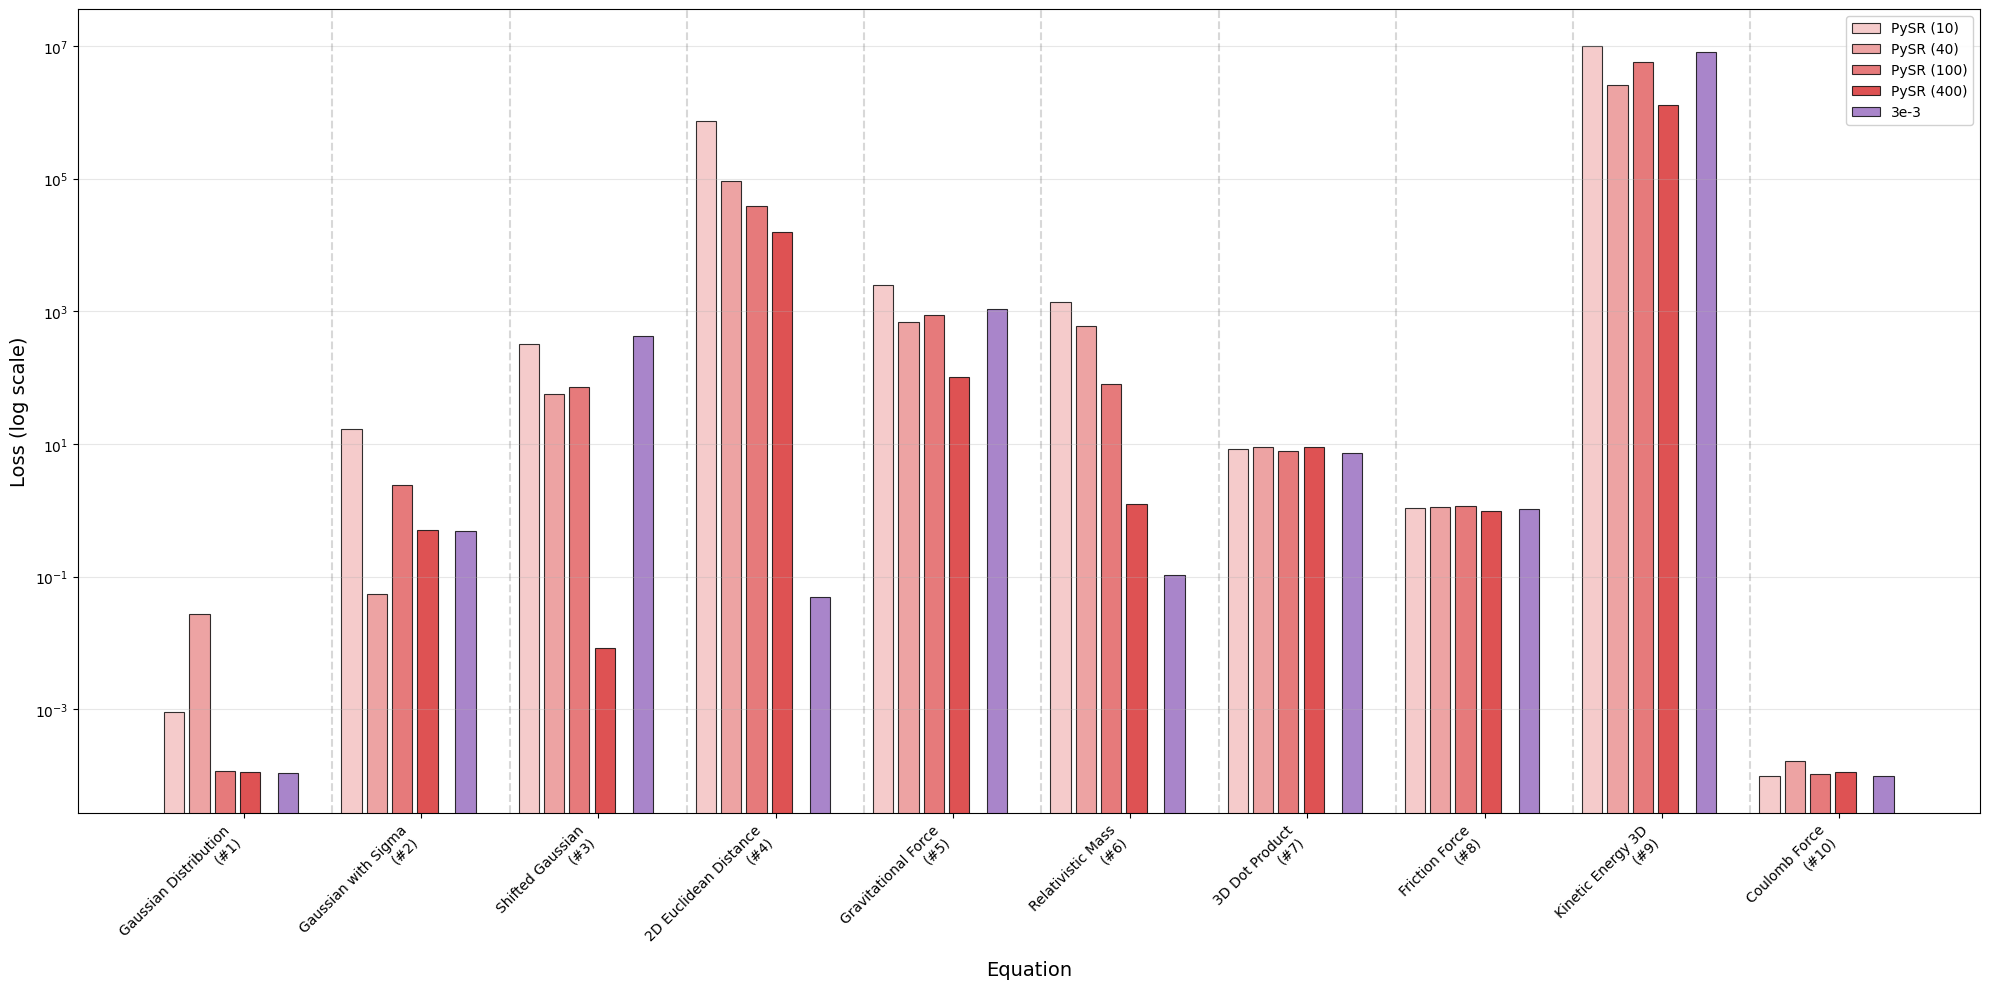


📊 Unified Plot Summary:
  • 10 equations plotted
  • 5 experiments compared
  • Using grouped bar chart with gradient color scheme

Saved best performers plot to /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison/feynman_comparison_best_performers_comparison.png


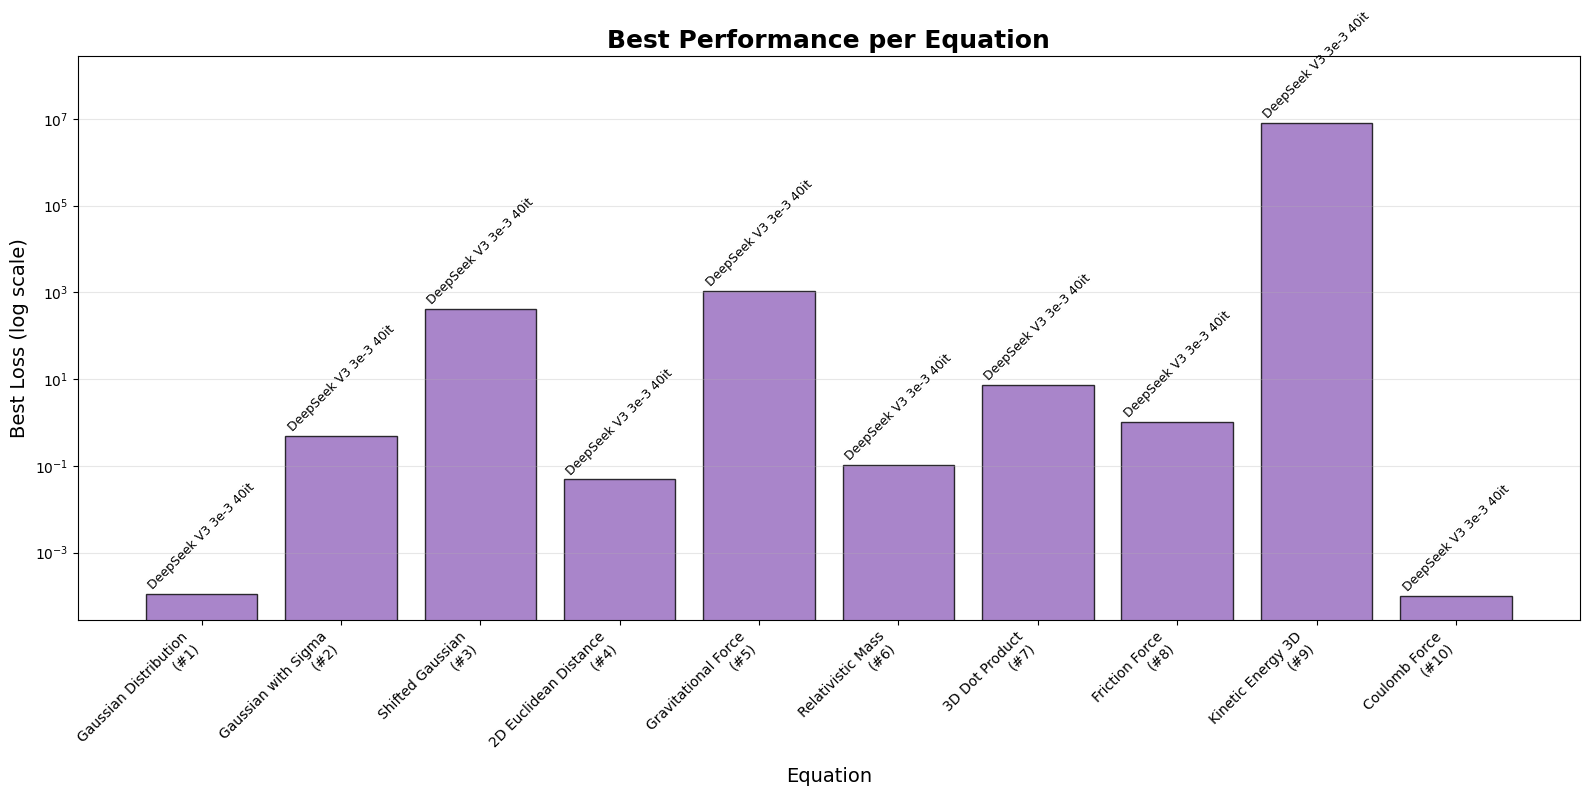


🏆 Best Performer Summary:
  • DeepSeek V3 3e-3 40it: 10 equations

Creating PySR Iterations vs Best LaSR Comparison Plot

Saved PySR iterations comparison plot to /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison/feynman_comparison_pysr_iterations_vs_lasr.png


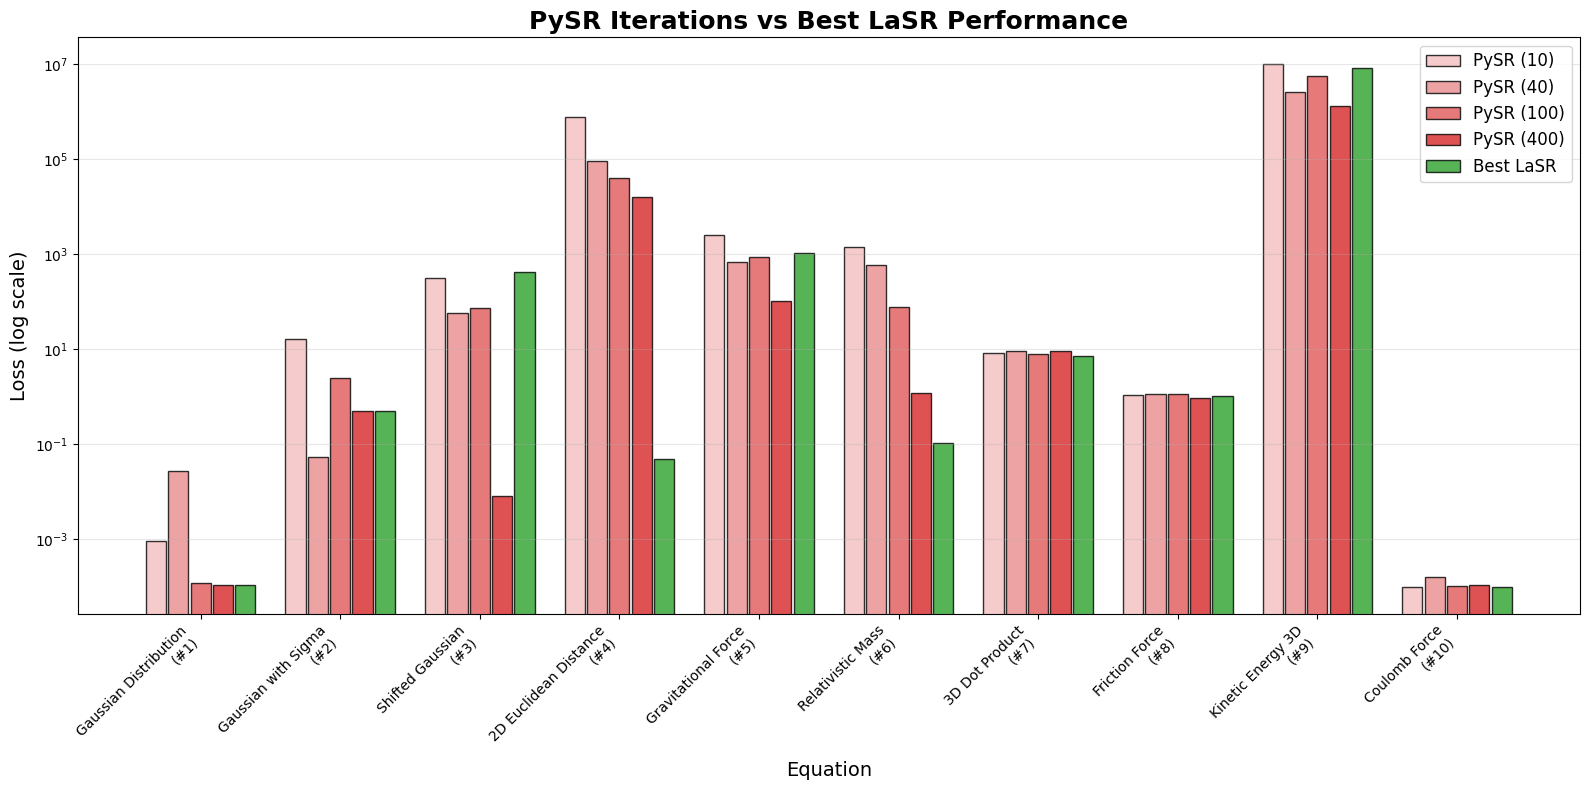

In [346]:
# Create unified comparison plot - either grouped or original style based on if_grouped parameter
# Use plot_equations if specified, otherwise use all equations
equations_to_plot = plot_equations if 'plot_equations' in locals() and plot_equations else all_equations

if if_grouped:
    # GROUPED BAR CHART WITH GRADIENT COLORS
    
    # Define experiment groups based on configuration
    if which_config == 1:
        experiment_groups_ordered = [
            ('PySR', ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000']),
            ('Llama3.2', [0, 5]),
            ('Qwen3-8B', [1, 6]),
            ('Qwen3-8B-think', [2, 7]),
            ('DeepSeek V3', [3, 8, 10, 11]),
            ('DeepSeek R1', [4, 12])
        ]
    elif which_config == 2:
        # Feynman dataset groups
        experiment_groups_ordered = [
            ('PySR', ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000']),
            ('DeepSeek V3', [0, 1])
        ]
    else:
        experiment_groups_ordered = [
            ('PySR', ['pysr_10', 'pysr_20', 'pysr_40', 'pysr_100', 'pysr_400', 'pysr_1000']),
            ('Llama3.2', [0, 1, 2, 3, 9]),
            ('Qwen3-8B', [4, 10]),
            ('Qwen3-8B-think', [5, 11]),
            ('DeepSeek V3', [6, 12]),
            ('DeepSeek R1', [7])
        ]

    # Prepare data for unified plot
    equation_labels = []
    for eq_num in equations_to_plot:
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        equation_labels.append(f'{eq_name}\n(#{eq_num})')

    # Create the unified plot with grouped bars
    fig, ax = plt.subplots(figsize=(20, 10))

    # Function to simplify labels
    def simplify_label(exp_key, original_label):
        """Simplify labels for better display"""
        if isinstance(exp_key, str) and exp_key.startswith('pysr_'):
            return f'PySR ({exp_key.split("_")[1]})'
        else:
            # For LASR experiments with suffixes
            if 'pw 40 it' in original_label:
                return 'pw(40)'
            elif ' pw' in original_label:
                return 'pw'
            elif ' 1e-2' in original_label:
                return '1e-2'
            elif ' 1e-3' in original_label:
                return '1e-3'
            elif ' 3e-3' in original_label:
                return '3e-3'
            else:
                # Return base name without suffix
                return original_label.split(' ')[0] + ' ' + original_label.split(' ')[1] if len(original_label.split(' ')) > 1 else original_label

    # Calculate positions for grouped bars
    x_positions = []
    x_labels_pos = []
    current_x = 0

    for eq_idx, eq_num in enumerate(equations_to_plot):
        eq_start = current_x
        
        # Plot each group
        for group_idx, (group_name, group_exps) in enumerate(experiment_groups_ordered):
            # Filter to only experiments with data for this equation
            active_exps = [exp for exp in group_exps if exp in exp_data and eq_num in exp_data[exp]]
            
            if active_exps:  # Only process groups with data
                for exp_idx, exp_key in enumerate(active_exps):
                    loss = exp_data[exp_key][eq_num]
                    color = exp_colors.get(exp_key, '#999999')
                    
                    # Get simplified label
                    label = None
                    if eq_idx == 0:  # Only add label for first equation to avoid duplicates
                        if exp_key in exp_labels:
                            label = simplify_label(exp_key, exp_labels[exp_key])
                        else:
                            label = simplify_label(exp_key, get_exp_label(exp_key))
                    
                    ax.bar(current_x, loss, width=0.8, label=label, 
                           color=color, alpha=0.8, edgecolor='black', linewidth=0.8)
                    current_x += 1
                
                # Add space between groups
                current_x += 0.5
        
        # Calculate center position for equation label
        eq_center = (eq_start + current_x - 0.5) / 2
        x_labels_pos.append(eq_center)
        
        # Add extra space between equations
        current_x += 1

    # Set x-axis labels
    ax.set_xticks(x_labels_pos)
    ax.set_xticklabels(equation_labels, rotation=45, ha='right')

    ax.set_xlabel('Equation', fontsize=14)
    ax.set_ylabel('Loss (log scale)', fontsize=14)
    ax.set_yscale('log')

    # Add vertical lines between equations
    for i in range(1, len(x_labels_pos)):
        x_sep = (x_labels_pos[i-1] + x_labels_pos[i]) / 2
        ax.axvline(x=x_sep, color='gray', linestyle='--', alpha=0.3)

    # Move legend inside the plot
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)

    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()

else:
    # ORIGINAL STYLE (NON-GROUPED)
    
    # Determine which experiments to plot based on pysr_overall parameter and plot_sequence
    plot_exp_keys = all_exp_keys.copy()
    if not pysr_overall and 'baseline' in plot_exp_keys:
        plot_exp_keys = [key for key in plot_exp_keys if key != 'baseline']

    # Apply plot_sequence if specified
    if 'plot_sequence' in locals() and plot_sequence:
        # Filter plot_exp_keys to only include those in plot_sequence and maintain the specified order
        ordered_keys = []
        for exp_key in plot_sequence:
            if exp_key in plot_exp_keys:
                ordered_keys.append(exp_key)
        plot_exp_keys = ordered_keys

    # Prepare data for unified plot
    equation_labels = []
    all_losses_by_exp = {exp_key: [] for exp_key in plot_exp_keys}

    for eq_num in equations_to_plot:
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        equation_labels.append(f'{eq_name}\n(#{eq_num})')
        
        # Collect losses for each experiment
        for exp_key in plot_exp_keys:
            if eq_num in exp_data[exp_key]:
                all_losses_by_exp[exp_key].append(exp_data[exp_key][eq_num])
            else:
                all_losses_by_exp[exp_key].append(np.nan)

    # Create the unified plot
    fig, ax = plt.subplots(figsize=(16, 8))

    x = np.arange(len(equation_labels))
    width = 0.8 / len(plot_exp_keys)  # Adjust bar width based on number of experiments

    # Plot bars for each experiment
    for i, exp_key in enumerate(plot_exp_keys):
        if exp_key in exp_labels:
            exp_label = exp_labels[exp_key]
        else:
            exp_label = get_exp_label(exp_key) if isinstance(exp_key, int) else exp_key
        color = exp_colors[exp_key] if exp_key in exp_colors else '#999999'
        
        # Calculate position offset for this experiment's bars
        offset = (i - len(plot_exp_keys)/2 + 0.5) * width
        
        # Plot bars, handling NaN values
        losses = all_losses_by_exp[exp_key]
        valid_indices = [j for j, loss in enumerate(losses) if not np.isnan(loss)]
        valid_losses = [losses[j] for j in valid_indices]
        valid_positions = [x[j] + offset for j in valid_indices]
        
        bars = ax.bar(valid_positions, valid_losses, width, 
                       label=exp_label, color=color, alpha=0.8, edgecolor='black')

    ax.set_xlabel('Equation', fontsize=14)
    ax.set_ylabel('Loss (log scale)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(equation_labels, rotation=45, ha='right')
    ax.set_yscale('log')

    # Move legend inside the plot
    ax.legend(fontsize=12, loc='upper right', framealpha=0.9)

    ax.grid(True, alpha=0.3, axis='y')

    # Add some padding to prevent bar cutoff
    ax.set_xlim(-0.5, len(equation_labels) - 0.5)

    plt.tight_layout()

# Save the unified plot
save_path = f'{output_dir}/{expr_name}_loss_comparison_overview.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved unified comparison plot to {save_path}")

plt.show()

# Print summary statistics for the unified plot
print(f"\n📊 Unified Plot Summary:")
print(f"  • {len(equations_to_plot)} equations plotted")
print(f"  • {total_experiments} experiments compared")
if if_grouped:
    print(f"  • Using grouped bar chart with gradient color scheme")
else:
    print(f"  • Using original non-grouped bar chart style")

# Also create a best performers comparison if multiple experiments
if total_experiments > 1:
    fig2, ax2 = plt.subplots(figsize=(16, 8))
    
    # For each equation, find the best performer
    best_losses = []
    best_methods = []
    best_colors = []
    
    for eq_idx, eq_num in enumerate(equations_to_plot):
        min_loss = float('inf')
        best_method = ''
        best_exp_key = None
        
        for exp_key in all_exp_keys:
            if eq_num in exp_data[exp_key]:
                if exp_data[exp_key][eq_num] < min_loss:
                    min_loss = exp_data[exp_key][eq_num]
                    best_exp_key = exp_key
                    if exp_key in exp_labels:
                        best_method = exp_labels[exp_key]
                    else:
                        best_method = get_exp_label(exp_key)
        
        if min_loss < float('inf'):
            best_losses.append(min_loss)
            best_methods.append(best_method)
            best_colors.append(exp_colors.get(best_exp_key, '#999999'))
        else:
            best_losses.append(np.nan)
            best_methods.append('No data')
            best_colors.append('#999999')
    
    x = np.arange(len(equation_labels))
    bars = ax2.bar(x, best_losses, color=best_colors, alpha=0.8, edgecolor='black')
    
    # Add method labels on top of bars
    for i, (bar, method) in enumerate(zip(bars, best_methods)):
        if not np.isnan(best_losses[i]):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                    method, ha='center', va='bottom', rotation=45, fontsize=9)
    
    ax2.set_xlabel('Equation', fontsize=14)
    ax2.set_ylabel('Best Loss (log scale)', fontsize=14)
    ax2.set_title('Best Performance per Equation', fontsize=18, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(equation_labels, rotation=45, ha='right')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Adjust y-limit to accommodate labels
    ax2.set_ylim(top=ax2.get_ylim()[1] * 10)
    
    plt.tight_layout()
    
    save_path2 = f'{output_dir}/{expr_name}_best_performers_comparison.png'
    plt.savefig(save_path2, dpi=300, bbox_inches='tight')
    print(f"\nSaved best performers plot to {save_path2}")
    
    plt.show()
    
    # Count wins per method
    win_counts = {}
    for method in best_methods:
        if method != 'No data':
            win_counts[method] = win_counts.get(method, 0) + 1
    
    print(f"\n🏆 Best Performer Summary:")
    for method, count in sorted(win_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  • {method}: {count} equations")

# Create PySR comparison plot (all iterations vs best LaSR)
pysr_keys_found = [k for k in exp_data.keys() if isinstance(k, str) and k.startswith('pysr_')]
if pysr_keys_found:
    print("\n" + "="*80)
    print("Creating PySR Iterations vs Best LaSR Comparison Plot")
    print("="*80)
    
    fig3, ax3 = plt.subplots(figsize=(16, 8))
    
    # Prepare data
    x = np.arange(len(equations_to_plot))
    width = 0.8 / (len(pysr_keys_found) + 1)  # +1 for best LaSR
    
    # Plot each PySR iteration
    for i, pysr_key in enumerate(sorted(pysr_keys_found, key=lambda x: int(x.split('_')[1]))):
        losses = []
        for eq_num in equations_to_plot:
            if eq_num in exp_data[pysr_key]:
                losses.append(exp_data[pysr_key][eq_num])
            else:
                losses.append(np.nan)
        
        offset = (i - len(pysr_keys_found)/2) * width
        color = exp_colors.get(pysr_key, '#999999')
        label = exp_labels.get(pysr_key, pysr_key)
        
        valid_indices = [j for j, loss in enumerate(losses) if not np.isnan(loss)]
        valid_losses = [losses[j] for j in valid_indices]
        valid_positions = [x[j] + offset for j in valid_indices]
        
        ax3.bar(valid_positions, valid_losses, width * 0.9, 
                label=label, color=color, alpha=0.8, edgecolor='black')
    
    # Add best LaSR for each equation
    best_lasr_losses = []
    for eq_num in equations_to_plot:
        lasr_losses = []
        for exp_key in available_experiments:
            if eq_num in exp_data[exp_key]:
                lasr_losses.append(exp_data[exp_key][eq_num])
        
        if lasr_losses:
            best_lasr_losses.append(min(lasr_losses))
        else:
            best_lasr_losses.append(np.nan)
    
    # Plot best LaSR
    offset = (len(pysr_keys_found) - len(pysr_keys_found)/2) * width
    valid_indices = [j for j, loss in enumerate(best_lasr_losses) if not np.isnan(loss)]
    valid_losses = [best_lasr_losses[j] for j in valid_indices]
    valid_positions = [x[j] + offset for j in valid_indices]
    
    ax3.bar(valid_positions, valid_losses, width * 0.9, 
            label='Best LaSR', color='#2ca02c', alpha=0.8, edgecolor='black')
    
    ax3.set_xlabel('Equation', fontsize=14)
    ax3.set_ylabel('Loss (log scale)', fontsize=14)
    ax3.set_title('PySR Iterations vs Best LaSR Performance', fontsize=18, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(equation_labels, rotation=45, ha='right')
    ax3.set_yscale('log')
    ax3.legend(fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    save_path3 = f'{output_dir}/{expr_name}_pysr_iterations_vs_lasr.png'
    plt.savefig(save_path3, dpi=300, bbox_inches='tight')
    print(f"\nSaved PySR iterations comparison plot to {save_path3}")
    
    plt.show()

In [347]:
# Create individual plots for each equation
if single_plot:
    # Use plot_equations if specified, otherwise use all equations
    equations_to_plot = plot_equations if 'plot_equations' in locals() and plot_equations else all_equations
    
    equation_stats_path = f'{output_dir}/{expr_name}_equation_statistics.txt'
    with open(equation_stats_path, 'w') as stats_file:
        for eq_num in equations_to_plot:
            plt.figure(figsize=(14, 7))
            
            losses_for_eq = []
            exp_names = []
            colors = []
            
            # Apply plot_sequence if specified
            exp_keys_to_plot = all_exp_keys.copy()
            if 'plot_sequence' in locals() and plot_sequence:
                # Filter exp_keys_to_plot to only include those in plot_sequence and maintain the specified order
                ordered_keys = []
                for exp_key in plot_sequence:
                    if exp_key in exp_keys_to_plot:
                        ordered_keys.append(exp_key)
                # Add any remaining experiments not in plot_sequence at the end
                for exp_key in exp_keys_to_plot:
                    if exp_key not in ordered_keys:
                        ordered_keys.append(exp_key)
                exp_keys_to_plot = ordered_keys
            
            for exp_key in exp_keys_to_plot:
                if eq_num in exp_data[exp_key]:
                    losses_for_eq.append(exp_data[exp_key][eq_num])
                    exp_names.append(get_exp_label(exp_key))  # Use get_exp_label instead of direct access
                    # Use consistent colors from exp_colors
                    if exp_key in exp_colors:
                        colors.append(exp_colors[exp_key])
                    else:
                        # Fallback color if not defined
                        colors.append('#999999')
            
            if losses_for_eq:
                bars = plt.bar(exp_names, losses_for_eq, color=colors, alpha=0.8, 
                            edgecolor='black', linewidth=1.2)
                plt.yscale('log')
                plt.xlabel('Experiment', fontsize=12)
                plt.ylabel('Loss (log scale)', fontsize=12)
                eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
                plt.title(f'{eq_name} (#{eq_num}) - {equation_info[eq_num]["formula"] if eq_num in equation_info else ""}', fontsize=14, fontweight='bold')
                plt.grid(True, alpha=0.3, axis='y')
                
                # Find best and worst performing experiments
                min_loss_idx = np.argmin(losses_for_eq)
                max_loss_idx = np.argmax(losses_for_eq)
                min_loss = losses_for_eq[min_loss_idx]
                
                # Add horizontal line showing the lowest loss
                plt.axhline(y=min_loss, color='green', linestyle='--', linewidth=2, alpha=0.7)
                
                # Add the minimum loss value to the y-axis ticks
                ax = plt.gca()
                yticks = list(ax.get_yticks())
                yticks.append(min_loss)
                yticks = sorted(set(yticks))
                ax.set_yticks(yticks)
                
                # Get the current y-tick labels and modify the one for min_loss
                yticklabels = []
                for tick in yticks:
                    if tick == min_loss:
                        yticklabels.append(f'{tick:.2e}')
                    else:
                        yticklabels.append(f'{tick:.2e}')
                ax.set_yticklabels(yticklabels)
                
                # Highlight the minimum loss tick
                for i, tick in enumerate(ax.yaxis.get_major_ticks()):
                    if yticks[i] == min_loss:
                        tick.label1.set_color('green')
                        tick.label1.set_weight('bold')
                
                # Compare against baseline if baseline exists for this equation
                baseline_idx = None
                if 'baseline' in exp_data and eq_num in exp_data['baseline']:
                    baseline_loss = exp_data['baseline'][eq_num]
                    # Find baseline index
                    for i, exp_key in enumerate(exp_keys_to_plot):
                        if exp_key == 'baseline':
                            baseline_idx = i
                            break
                    
                    if baseline_idx is not None:
                        # Count how many LASR experiments beat the baseline
                        better_than_baseline = sum(1 for i, loss in enumerate(losses_for_eq) 
                                                if i != baseline_idx and loss < baseline_loss)
                        total_lasr = len(losses_for_eq) - 1  # -1 for baseline
                
                # Make x-axis labels angled like in overall plot
                plt.xticks(rotation=45, ha='right')
                
                plt.tight_layout()
                
                # Save the plot in the experiment folder
                save_path = f'{output_dir}/{expr_name}_equation_{eq_num}_loss_comparison.png'
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Saved plot to {save_path}")
                
                plt.show()
                
                # Write statistics to file
                eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
                stats_file.write(f"\nStatistics for {eq_name} (#{eq_num}):\n")
                if eq_num in equation_info:
                    stats_file.write(f"  Formula: {equation_info[eq_num]['formula']}\n")
                    stats_file.write(f"  Description: {equation_info[eq_num]['description']}\n")
                stats_file.write(f"  Total experiments: {len(losses_for_eq)}")
                if has_baseline:
                    stats_file.write(f" (1 Baseline + {len(losses_for_eq)-1} LASR)\n")
                else:
                    stats_file.write(f" (all LASR)\n")
                stats_file.write(f"  Best performance: {exp_names[min_loss_idx]} with loss {losses_for_eq[min_loss_idx]:.2e}\n")
                stats_file.write(f"  Worst performance: {exp_names[max_loss_idx]} with loss {losses_for_eq[max_loss_idx]:.2e}\n")
                stats_file.write(f"  Loss ratio (worst/best): {losses_for_eq[max_loss_idx]/losses_for_eq[min_loss_idx]:.2e}\n")
                
                if 'baseline' in exp_data and eq_num in exp_data['baseline'] and baseline_idx is not None:
                    baseline_loss = exp_data['baseline'][eq_num]
                    better_than_baseline = sum(1 for i, loss in enumerate(losses_for_eq) 
                                            if i != baseline_idx and loss < baseline_loss)
                    total_lasr = len(losses_for_eq) - 1
                    stats_file.write(f"  LASR experiments better than baseline: {better_than_baseline}/{total_lasr}\n")
                    if baseline_idx != min_loss_idx:
                        improvement = baseline_loss / losses_for_eq[min_loss_idx]
                        stats_file.write(f"  Best LASR improvement over baseline: {improvement:.2f}x better\n")
                
                stats_file.write("-" * 60 + "\n")

    # Also save equation statistics as CSV in the experiment folder
    equation_stats_df = []
    for eq_num in equations_to_plot:
        eq_name = equation_info[eq_num]['name'] if eq_num in equation_info else f'Eq #{eq_num}'
        eq_stats = {'Equation': eq_name, 'Equation_Number': eq_num}
        
        # Get losses for this equation
        losses_for_eq = []
        exp_names_for_eq = []
        for exp_key in all_exp_keys:
            if eq_num in exp_data[exp_key]:
                losses_for_eq.append(exp_data[exp_key][eq_num])
                exp_names_for_eq.append(get_exp_label(exp_key))
        
        if losses_for_eq:
            min_idx = np.argmin(losses_for_eq)
            max_idx = np.argmax(losses_for_eq)
            
            eq_stats['Best_Method'] = exp_names_for_eq[min_idx]
            eq_stats['Best_Loss'] = losses_for_eq[min_idx]
            eq_stats['Worst_Method'] = exp_names_for_eq[max_idx]
            eq_stats['Worst_Loss'] = losses_for_eq[max_idx]
            eq_stats['Loss_Ratio'] = losses_for_eq[max_idx] / losses_for_eq[min_idx]
            
            if 'baseline' in exp_data and eq_num in exp_data['baseline']:
                baseline_loss = exp_data['baseline'][eq_num]
                baseline_idx = next((i for i, name in enumerate(exp_names_for_eq) if name == exp_labels.get('baseline', 'PySR (Baseline)')), None)
                if baseline_idx is not None:
                    better_count = sum(1 for i, loss in enumerate(losses_for_eq) if i != baseline_idx and loss < baseline_loss)
                    eq_stats['LASR_Better_Than_Baseline'] = better_count
                    eq_stats['Total_LASR'] = len(losses_for_eq) - 1
                    if baseline_idx != min_idx:
                        eq_stats['Best_Improvement_Over_Baseline'] = baseline_loss / losses_for_eq[min_idx]
                    else:
                        eq_stats['Best_Improvement_Over_Baseline'] = 1.0
            
            equation_stats_df.append(eq_stats)

    equation_stats_df = pd.DataFrame(equation_stats_df)
    equation_stats_csv_path = f'{output_dir}/{expr_name}_equation_statistics.csv'
    equation_stats_df.to_csv(equation_stats_csv_path, index=False)
    
    print(f"\n📊 Files saved in {output_dir}:")
    print(f"  • {expr_name}_loss_comparison_summary.csv")
    print(f"  • {expr_name}_loss_comparison_overview.png")
    if has_baseline:
        print(f"  • {expr_name}_pysr_vs_lasr_comparison.png")
    print(f"  • {expr_name}_equation_statistics.txt")
    print(f"  • {expr_name}_equation_statistics.csv")
    print(f"  • {expr_name}_extraction_log.txt")
    if single_plot:
        print(f"  • Individual equation plots: {expr_name}_equation_N_loss_comparison.png")
else:
    print(f"\n📊 Files saved in {output_dir}:")
    print(f"  • {expr_name}_loss_comparison_summary.csv")
    print(f"  • {expr_name}_loss_comparison_overview.png")
    if has_baseline:
        print(f"  • {expr_name}_pysr_vs_lasr_comparison.png")
    print(f"  • {expr_name}_extraction_log.txt")


📊 Files saved in /Users/xiaobocheng/final_project/image/feynman/loss_plot/feynman_comparison:
  • feynman_comparison_loss_comparison_summary.csv
  • feynman_comparison_loss_comparison_overview.png
  • feynman_comparison_extraction_log.txt


In [348]:
# Execute the modified cell to generate the unified plot
exec(open('/Users/xiaobocheng/final_project/LibraryAugmentedSymbolicRegression.jl/loss_comparison_analysis.ipynb').read())

NameError: name 'null' is not defined